# UNET

Architecture basée sur cet  [article](https://arxiv.org/abs/1505.04597)

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

from skimage.transform import resize

import keras

from keras import Model
from keras.layers import (
    Input, Reshape, Resizing, Rescaling, Flatten, Concatenate,
    BatchNormalization, Convolution2D, MaxPooling2D, UpSampling2D)

from keras.optimizers import Adam
from keras.losses import MeanSquaredError

from keras.utils import plot_model
from utils import load_mnist_noised, get_lc, plot_ae_results

from typing import Tuple

In [2]:
(x_train, y_train, y_label), (x_test, y_test, y_label) = load_mnist_noised(0.30, 0.30)
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [3]:
def preprocessing(input_shape: Tuple[int], reshape_shape: Tuple[int], resizing_shape: Tuple[int], name: str = 'preprocessing') -> Model:
    inputs = Input(input_shape)
    x = Reshape(reshape_shape)(inputs)
    x = Resizing(*resizing_shape)(x)
    x = Rescaling(1./255)(x)
    
    return Model(inputs=inputs, outputs=x, name=name)

def conv_block(input_shape: Tuple[int], name: str = None, **kwargs) -> Model:
    inputs = Input(input_shape)
    x = Convolution2D(**kwargs)(inputs)
    x = BatchNormalization()(x)
    x = Convolution2D(**kwargs)(x)
    skip = BatchNormalization()(x)
    x = MaxPooling2D(2, strides=2)(skip)

    return Model(inputs=inputs, outputs=[x, skip], name=name)

def upsampling_block(input_shape: Tuple[int], name: str = None, **kwargs) -> Model:
    inputs = Input(input_shape)
    
    x = Convolution2D(**kwargs)(inputs)
    x = BatchNormalization()(x)
    x = Convolution2D(**kwargs)(x)
    x = BatchNormalization()(x)
    
    x = UpSampling2D()(x)

    return Model(inputs=inputs, outputs=x, name=name)

def out_upsampling(input_shape: Tuple[int], name: str = None, **kwargs) -> Model:
        inputs = Input(input_shape)

        x = Convolution2D(**kwargs)(inputs)
        x = BatchNormalization()(x)
        x = Convolution2D(**kwargs)(x)
        x = BatchNormalization()(x)

        x = Convolution2D(1, 1, activation='linear')(x)

        return Model(inputs=inputs, outputs=x, name=name)


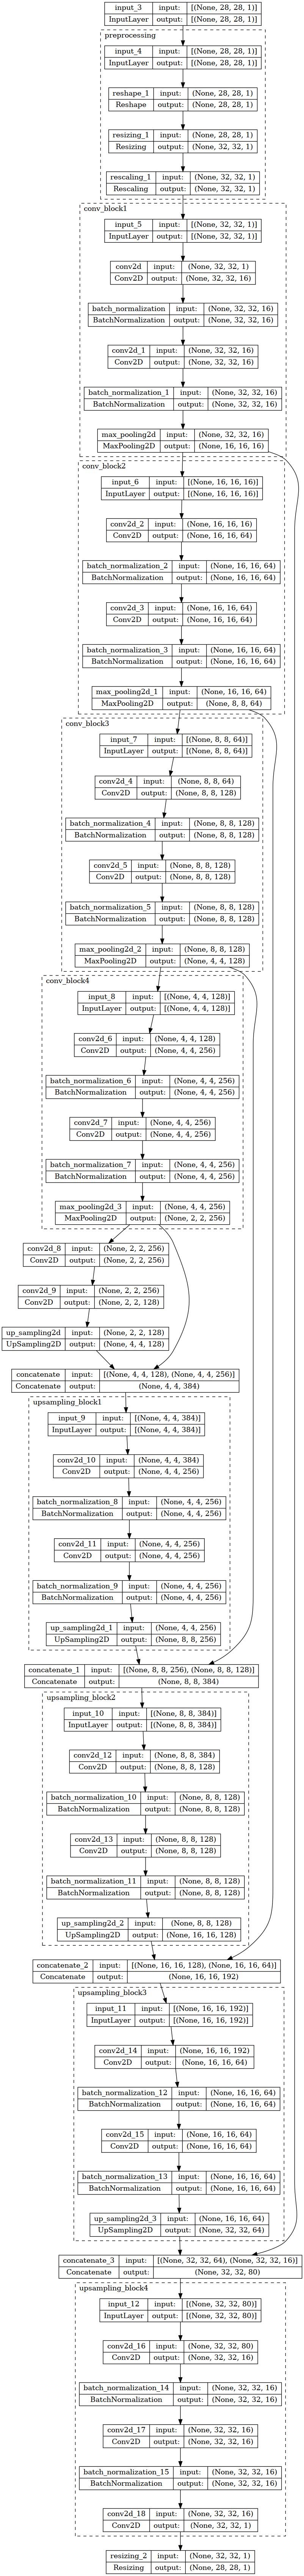

In [5]:
INPUT_SHAPE = (28, 28, 1)
filters = 16

inputs = Input(INPUT_SHAPE)
x = preprocessing(inputs.shape[1:], reshape_shape=(28, 28, 1), resizing_shape=(32, 32))(inputs)

x, skip1 = conv_block(x.shape[1:], name='conv_block1', filters=filters, kernel_size=3, activation='gelu', padding='same')(x)
x, skip2 = conv_block(x.shape[1:], name='conv_block2', filters=filters*(2**2), kernel_size=3, activation='gelu', padding='same')(x)
x, skip3 = conv_block(x.shape[1:], name='conv_block3', filters=filters*(2**3), kernel_size=3, activation='gelu', padding='same')(x)
x, skip4 = conv_block(x.shape[1:], name='conv_block4', filters=filters*(2**4), kernel_size=3, activation='gelu', padding='same')(x)

x = Convolution2D(filters=filters*(2**4), kernel_size=1, activation='gelu', padding='same')(x)
x = Convolution2D(filters=filters*(2**3), kernel_size=1, activation='gelu', padding='same')(x)
x = UpSampling2D()(x)

x = Concatenate()([x, skip4])
x = upsampling_block(x.shape[1:], name='upsampling_block1', filters=filters*(2**4), kernel_size=3, activation='gelu', padding='same')(x)

x = Concatenate()([x, skip3])
x = upsampling_block(x.shape[1:], name='upsampling_block2', filters=filters*(2**3), kernel_size=3, activation='gelu', padding='same')(x)

x = Concatenate()([x, skip2])
x = upsampling_block(x.shape[1:], name='upsampling_block3', filters=filters*(2**2), kernel_size=3, activation='gelu', padding='same')(x)

x = Concatenate()([x, skip1])
x = out_upsampling(x.shape[1:], name='upsampling_block4', filters=filters, kernel_size=3, activation='gelu', padding='same')(x)
x = Resizing(*(28, 28))(x)

unet = Model(inputs=inputs, outputs=x, name='unet')
plot_model(unet, show_shapes=True, expand_nested=True)

Epoch 1/30


47/47 [==============================] - ETA: 0s - loss: 0.1435

47/47 [==============================] - 37s 406ms/step - loss: 0.1435 - val_loss: 0.1026
Epoch 2/30
47/47 [==============================] - 8s 162ms/step - loss: 0.0376 - val_loss: 0.1166
Epoch 3/30
47/47 [==============================] - 6s 137ms/step - loss: 0.0342 - val_loss: 0.1360
Epoch 4/30
47/47 [==============================] - 6s 120ms/step - loss: 0.0319 - val_loss: 0.1302
Epoch 5/30
47/47 [==============================] - 6s 118ms/step - loss: 0.0301 - val_loss: 0.1163
Epoch 6/30
47/47 [==============================] - 6s 128ms/step - loss: 0.0287 - val_loss: 0.1097
Epoch 7/30
47/47 [==============================] - 6s 134ms/step - loss: 0.0274 - val_loss: 0.1145
Epoch 8/30
47/47 [==============================] - 6s 134ms/step - loss: 0.0264 - val_loss: 0.1137
Epoch 9/30
47/47 [==============================] - 6s 133ms/step - loss: 0.0256 - val_loss: 0.1139
Epoch 10/30
47/47 [==============================] - 6s 128ms/step - loss: 0.0249 - val_loss: 0.1098
Epoch 11/

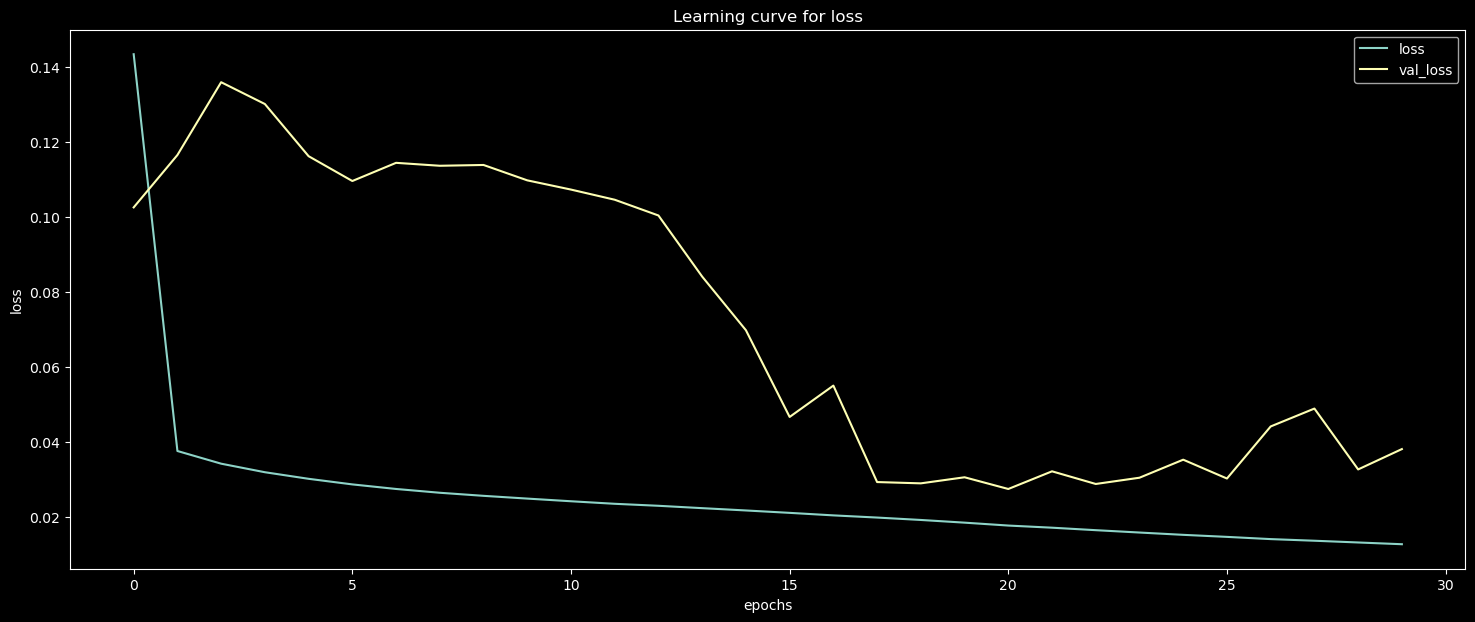

In [6]:
unet.compile(
    optimizer = Adam(),
    loss = MeanSquaredError()
)

unet.fit(x_train, y_train, epochs=30, batch_size=1024, validation_split=.2)
get_lc(unet.history.history)

In [ ]:
y_pred = unet.predict(x_test)

313/313 [==============================] - 2s 5ms/step


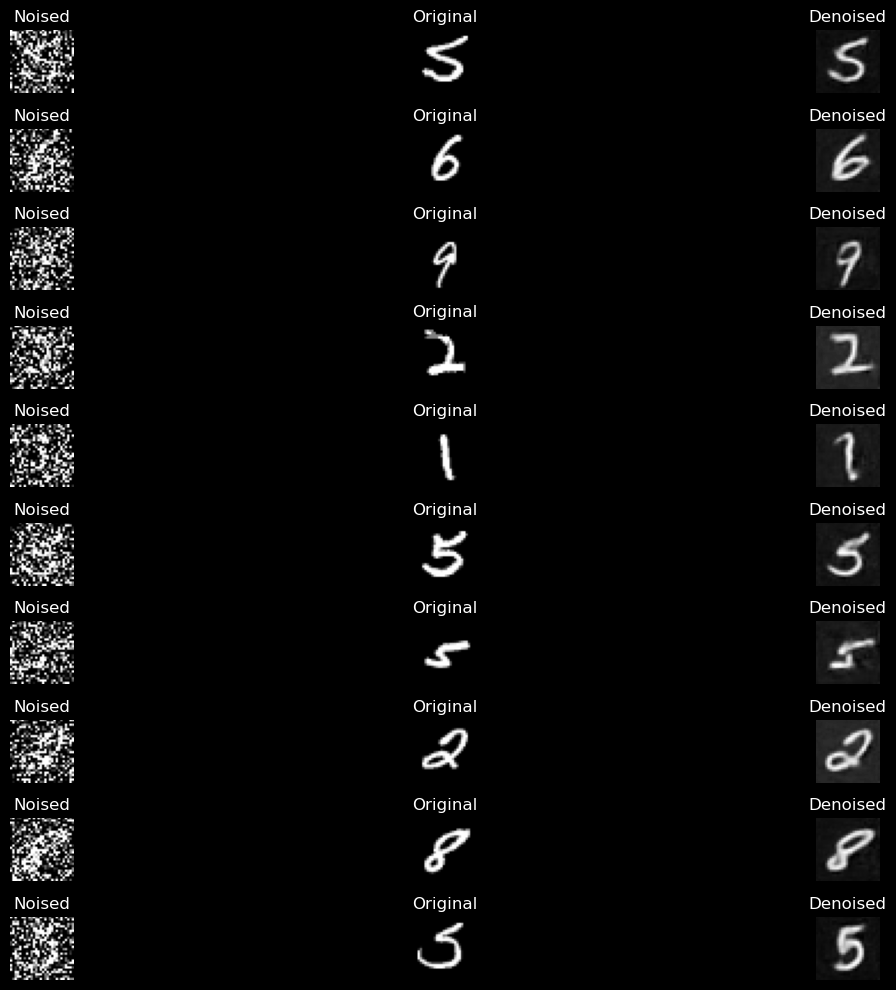

In [ ]:
plot_ae_results(10, x_test, y_test, y_pred)